<a href="https://colab.research.google.com/github/MACHARODRIGO/04-protein-ligand-genomegym-beginner/blob/main/protein_ligand_beginner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Protein-Ligand Beginner

## 📖 Introduction
Brief overview of what we will do:
- Load a protein structure with Gemmi
- Represent a ligand with RDKit
- Extract basic structural and chemical data

## ⚙️ Install Dependencies

This notebook requires **RDKit** and **Gemmi**.  
- RDKit: cheminformatics toolkit (PyPI wheel available).  
- Gemmi: crystallographic library (compiled directly from source when using Colab).  

If you are running on **Google Colab**, execute the cell below:

In [1]:
# RDKit (official wheel from PyPI)
!pip install rdkit

# Gemmi (official source from GitHub, fast build)
!pip install gemmi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 60.9 MB/s eta 0:00:00


If you are running **locally with Conda**, it is recommended to install from conda-forge:

conda create -n protein-beginner python=3.9

conda activate protein-beginner

conda install -c conda-forge gemmi rdkit


## 📂 1. Protein Structure with Gemmi

### 1.1 Define directory where PDB files will be stored


In [2]:
import os
import gemmi
import urllib.request

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Define directory where PDB files will be stored
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)  # Create directory if it doesn't exist

def download_pdb(pdb_id: str):
    """
    Download a PDB file from the RCSB Protein Data Bank.
    Only downloads if the file is not already in DATA_DIR.

    Args:
        pdb_id (str): The 4-letter PDB identifier, e.g. "1CRN"

    Returns:
        filepath (str): Path to the downloaded PDB file
    """
    filename = f"{pdb_id}.pdb"                  # File will be saved as "1CRN.pdb"
    filepath = os.path.join(DATA_DIR, filename) # Full path inside 'data/' folder
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"  # Download URL

    # Download only if file is missing
    if not os.path.exists(filepath):
        urllib.request.urlretrieve(url, filepath)
        print(f"✅ Downloaded {filename}")
    return filepath


### 1.2 Example with Crambin (PDB ID: 1CRN)

In [3]:
pdb_file = download_pdb("1CRN")         # Download PDB file
structure = gemmi.read_structure(pdb_file)  # Parse file with gemmi
model = structure[0]                        # Select first model (common in X-ray structures)

# Print number of chains in the model
print(f"Model contains {len(model)} chains.")
for chain in model:
    print(f"Chain {chain.name}: {len(chain)} residues")

# ----------------
# Explore residues
# ----------------
# Print the first 5 residues (name + sequence ID)

print("\nFirst 5 residues:")
for res in model[0][:5]:  # model[0] = first chain
    print(res.name, res.seqid.num)

# ----------------
# Inspect atoms
# ----------------
# Take the first atom of the first residue in the first chain

atom = model[0][0][0]
print("\nFirst atom:", atom.name, atom.pos)  # Atom name and 3D coordinates

✅ Downloaded 1CRN.pdb
Model contains 1 chains.
Chain A: 46 residues

First 5 residues:
THR 1
THR 2
CYS 3
CYS 4
PRO 5

First atom: N <gemmi.Position(17.047, 14.099, 3.625)>


### 1.3 Multi-protein analysis with Gemmi

In [4]:
# Define a list of PDB IDs to analyze
pdb_list = ["1CRN", "4HHB", "1A3N"]  # Crambin, Hemoglobin, Lysozyme (examples)

for pdb_id in pdb_list:
    # ----------------
    # Download and load protein
    # ----------------
    pdb_file = download_pdb(pdb_id)             # Download PDB file if missing
    structure = gemmi.read_structure(pdb_file)  # Parse file with Gemmi
    model = structure[0]                        # Select the first model

    # ----------------
    # Print chain summary
    # ----------------
    print(f"\n📂 {pdb_id}.pdb")
    print(f"Model contains {len(model)} chains.")
    for chain in model:
        print(f"  Chain {chain.name}: {len(chain)} residues")

    # ----------------
    # Explore residues
    # ----------------
    # Print the first 5 residues of the first chain (if chain has enough residues)
    if len(model[0]) >= 5:
        print("\n  First 5 residues:")
        for res in model[0][:5]:
            print(f"   {res.name} {res.seqid.num}")
    else:
        print("\n  Chain too short to show 5 residues.")

    # ----------------
    # Inspect atoms
    # ----------------
    # Show the first atom of the first residue in the first chain
    atom = model[0][0][0]
    print(f"\n  First atom: {atom.name} {atom.pos}")




📂 1CRN.pdb
Model contains 1 chains.
  Chain A: 46 residues

  First 5 residues:
   THR 1
   THR 2
   CYS 3
   CYS 4
   PRO 5

  First atom: N <gemmi.Position(17.047, 14.099, 3.625)>
✅ Downloaded 4HHB.pdb

📂 4HHB.pdb
Model contains 4 chains.
  Chain A: 198 residues
  Chain B: 205 residues
  Chain C: 201 residues
  Chain D: 197 residues

  First 5 residues:
   VAL 1
   LEU 2
   SER 3
   PRO 4
   ALA 5

  First atom: N <gemmi.Position(19.323, 29.727, 42.781)>
✅ Downloaded 1A3N.pdb

📂 1A3N.pdb
Model contains 4 chains.
  Chain A: 265 residues
  Chain B: 259 residues
  Chain C: 242 residues
  Chain D: 261 residues

  First 5 residues:
   VAL 1
   LEU 2
   SER 3
   PRO 4
   ALA 5

  First atom: N <gemmi.Position(10.72, 19.523, 6.163)>


## ⚗️ 2. Small Molecule with RDKit



In [5]:

import os
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors
from IPython.display import Image, display

# Define results directory for saving molecule images
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


### 2.1 Single molecule example (Ethanol)

In [6]:
smiles = "CCO"  # ethanol
mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("❌ Invalid SMILES string: molecule could not be loaded.")
else:
    print("\n✅ Molecule loaded successfully")

# Print molecular properties
print("Molecular formula:", rdMolDescriptors.CalcMolFormula(mol))
print("Molecular weight:", Descriptors.MolWt(mol))

# Save 2D visualization to results folder
img_path = os.path.join(RESULTS_DIR, "ethanol.png")
Draw.MolToFile(mol, img_path, size=(300, 300))
print(f"🖼️ Molecule image saved to {img_path}")



✅ Molecule loaded successfully
Molecular formula: C2H6O
Molecular weight: 46.069
🖼️ Molecule image saved to results/ethanol.png


### 2.2 Multiple molecules
In this step we will:  
- Calculate its molecular formula and weight  
- Generate and save a 2D image (`ethanol.png`)


🔬 Ethanol
  Formula: C2H6O
  Weight: 46.069
  🖼️ Image saved to results/ethanol.png

🔬 Benzene
  Formula: C6H6
  Weight: 78.11399999999999
  🖼️ Image saved to results/benzene.png

🔬 Aspirin
  Formula: C9H8O4
  Weight: 180.15899999999996
  🖼️ Image saved to results/aspirin.png


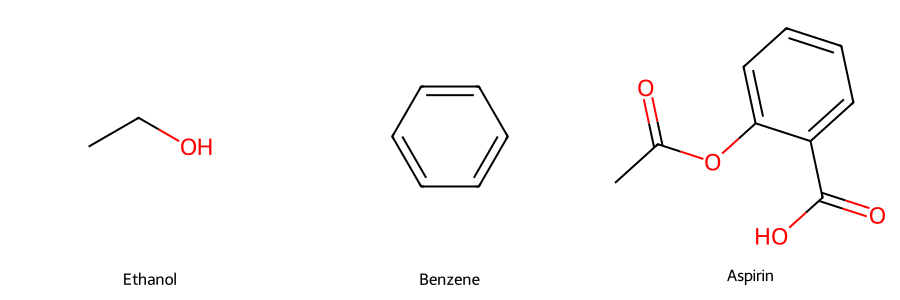

In [9]:
smiles_dict = {
    "Ethanol": "CCO",
    "Benzene": "c1ccccc1",
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O"
}

# Lists to store molecules and names for final visualization
mols = []
names = []

for name, smi in smiles_dict.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"\n❌ Could not load {name} (invalid SMILES)")
        continue

    # If the molecule is loaded successfully, add it to the lists
    mols.append(mol)
    names.append(name)

    # Print molecular properties (as in your original code)
    print(f"\n🔬 {name}")
    print("  Formula:", rdMolDescriptors.CalcMolFormula(mol))
    print("  Weight:", Descriptors.MolWt(mol))

    # Save the individual image (as in your original code)
    img_file = f"{name.lower()}.png"
    img_path = os.path.join(RESULTS_DIR, img_file)
    Draw.MolToFile(mol, img_path, size=(300, 300))
    print(f"  🖼️ Image saved to {img_path}")

# Display all molecules in a single row in the notebook
if mols:
    grid_img = Draw.MolsToGridImage(mols, molsPerRow=len(mols), subImgSize=(300, 300), legends=names)
    display(grid_img)